Applying Tversky transformations to environmental audio

In [1]:
# imports

import torch
from torch.utils.data import DataLoader
import torchvision.transforms as tt
import torchvision.models as models
import math

import torch.nn as nn

import torch.nn.functional as F

from pyha_analyzer.preprocessors import MelSpectrogramPreprocessors
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
config = {
    "learning_rate": 10e-3,
    "learning_rate_decay": 0.001,
    "device": 'cuda',
    "seed": 1
}

In [3]:
torch.manual_seed(config["seed"])

In [4]:
from datasets import load_dataset

mnist_dataset = load_dataset("mnist")

train = mnist_dataset["train"]
test = mnist_dataset["test"]

def transform(batch):
  t = tt.Compose([
    tt.Grayscale(num_output_channels=3),
    tt.PILToTensor(),
    tt.ConvertImageDtype(torch.float)
    ])
  
  batch['image'] = [t(img) for img in batch['image']]
  batch['label'] = F.one_hot(torch.tensor(batch['label']), num_classes=10)
  
  return batch

train.set_transform(transform)
test.set_transform(transform)

In [10]:
transform

<function __main__.transform(batch)>

In [5]:
# # simplest implementation

# alpha = 0.1
# beta = 0.1
# theta = 0.1
# phi = torch.mul
# substract = True
# batch_size = (8,)
# feature_count = (20,)
# feature_shape = (1, 28, 28)
# class_count = (12,)

# batch = torch.rand(batch_size + feature_shape)

# f = torch.rand(feature_count + feature_shape)
# pi = torch.rand(class_count + feature_shape)


# output = []
# for a in batch:
#     batch_output = []
#     for p in pi:
#         a_f = torch.sum(a * f, (-1, -2, -3))
#         p_f = torch.sum(p * f, (-1, -2, -3))

#         val = phi(a_f, p_f)

#         mask = (torch.minimum(a_f, p_f) <= 0).int()

#         intersection = theta * (val * mask).sum()

#         if substract:
#             alpha_difference = -alpha * (a_f * ((a_f > 0) | (p_f <= 0)).int()).sum()
#             beta_difference = -beta * (p_f * ((p_f > 0) | (a_f <= 0)).int()).sum()
#         else:
#             alpha_difference = -alpha * ((a_f - p_f) * ((a_f > 0) | (p_f > 0) | (a_f > p_f)).int()).sum()
#             beta_difference = -beta * ((p_f - a_f) * ((p_f > 0) | (a_f > 0) | (p_f > a_f)).int()).sum()
        
#         batch_output.append(float(intersection + alpha_difference + beta_difference))
#     output.append(batch_output)
# output1 = torch.tensor(output)
# print(output1)

# def Tversky():
    
#     a_f = (batch.flatten(1, -1).unsqueeze(1) * f.flatten(1, -1).unsqueeze(0)).sum(-1).unsqueeze(1)
#     p_f = (pi.flatten(1, -1).unsqueeze(1) * f.flatten(1, -1).unsqueeze(0)).sum(-1).unsqueeze(0)
    

#     val = phi(a_f, p_f)
#     mask = (torch.minimum(a_f, p_f) <= 0).int()
#     intersection = theta * (val * mask).sum(-1)
    
#     if substract:
#         alpha_difference = -alpha * (a_f * ((a_f > 0) | (p_f <= 0)).int()).sum(-1)
#         beta_difference = -beta * (p_f * ((p_f > 0) | (a_f <= 0)).int()).sum(-1)
#     else:
#         alpha_difference = -alpha * ((a_f - p_f) * ((a_f > 0) | (p_f > 0) | (a_f > p_f)).int()).sum(-1)
#         beta_difference = -beta * ((p_f - a_f) * ((p_f > 0) | (a_f > 0) | (p_f > a_f)).int()).sum(-1)
    
#     return intersection + alpha_difference + beta_difference

In [6]:
class Tversky(nn.Module):
    """
    Similar to a fully-connected layer, but computes Tversky similarity instead
    """
    def __init__(
        self,
        num_classes: int,
        feature_shape: tuple,
        num_features=256,
        feature_bank=None,
        phi=torch.mul,
        substract=True,
        device=None,
        dtype=None
    ) -> None:
        factory_kwargs = {"device": device, "dtype": dtype}
        super().__init__()
        
        self.feature_shape = feature_shape
        
        self.phi = phi
        self.substract = substract
        
        if feature_bank is None:
            self.feature_bank = nn.Parameter(
                torch.empty((num_features,) + feature_shape, **factory_kwargs)
            )
        else:
            self.feature_bank = feature_bank
            
        self.prototypes = nn.Parameter(
                torch.empty( (num_classes,) + feature_shape, **factory_kwargs)
            )
            
        self.alpha = nn.Parameter(torch.empty(1))
        self.beta = nn.Parameter(torch.empty(1))
        self.theta = nn.Parameter(torch.empty(1))

        self.reset_parameters()
        
    def reset_parameters(self) -> None:
        nn.init.uniform_(self.feature_bank)
        nn.init.uniform_(self.prototypes)
        nn.init.normal_(self.alpha)
        nn.init.normal_(self.beta)
        nn.init.normal_(self.theta)
    
    def forward(self, input: torch.Tensor):
        
        a_f = (input.flatten(1, -1).unsqueeze(1) * self.feature_bank.flatten(1, -1).unsqueeze(0)).sum(-1).unsqueeze(1)
        p_f = (self.prototypes.flatten(1, -1).unsqueeze(1) * self.feature_bank.flatten(1, -1).unsqueeze(0)).sum(-1).unsqueeze(0)
        

        val = self.phi(a_f, p_f)
        mask = (torch.minimum(a_f, p_f) <= 0).int()
        intersection = self.theta * (val * mask).sum(-1)
        
        
        if self.substract:
            alpha_difference = -self.alpha * (a_f * ((a_f > 0) | (p_f <= 0)).int()).sum(-1)
            beta_difference = -self.beta * (p_f * ((p_f > 0) | (a_f <= 0)).int()).sum(-1)
        else:
            alpha_difference = -self.alpha * ((a_f - p_f) * ((a_f > 0) | (p_f > 0) | (a_f > p_f)).int()).sum(-1)
            beta_difference = -self.beta * ((p_f - a_f) * ((p_f > 0) | (a_f > 0) | (p_f > a_f)).int()).sum(-1)
        
        return intersection + alpha_difference + beta_difference

In [7]:
ResNet_Linear = models.resnet50(weights=None)
ResNet_Linear.fc = torch.nn.Linear(ResNet_Linear.fc.in_features, 10)

linear_model = nn.Sequential(
    nn.Upsample(size=(224, 224), mode='bilinear', align_corners=False),
    ResNet_Linear
).to(config['device'])

In [8]:
optimizer = torch.optim.AdamW(linear_model.parameters(), weight_decay=0, lr=config["learning_rate"], betas=(0.8, 0.999))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda epoch : (1-config["learning_rate_decay"])**epoch)
metric = torch.nn.CrossEntropyLoss()
train_loader = DataLoader(mnist_dataset['train'], batch_size=8, num_workers=1, shuffle=True, pin_memory=True, pin_memory_device=config['device'])

In [9]:
step, loss = 0, []

correct, total = 0, 0

for epoch in range(5):
    for data in tqdm(train_loader, desc=str(epoch), leave=False):
        img = data['image']

        optimizer.zero_grad()
        x = img.to(config["device"])
        
        pred = linear_model(x)
        
        label = data['label'].to(config["device"], torch.float)
        
        score = metric(pred, label)
        
        score.backward()
        optimizer.step()
        
        loss.append(score.item())
        
        
        if step % 500 == 0:
            with torch.no_grad():
                print(np.mean(loss[-100:-1]))
            
        step += 1

0:   0%|          | 0/7500 [00:00<?, ?it/s]

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/anu/.local/share/uv/python/cpython-3.11.6-macos-aarch64-none/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/anu/.local/share/uv/python/cpython-3.11.6-macos-aarch64-none/lib/python3.11/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'transform' on <module '__main__' (built-in)>


RuntimeError: DataLoader worker (pid(s) 13530) exited unexpectedly

In [ ]:
ResNet_Linear

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

TypeError: plot() got an unexpected keyword argument 'x'

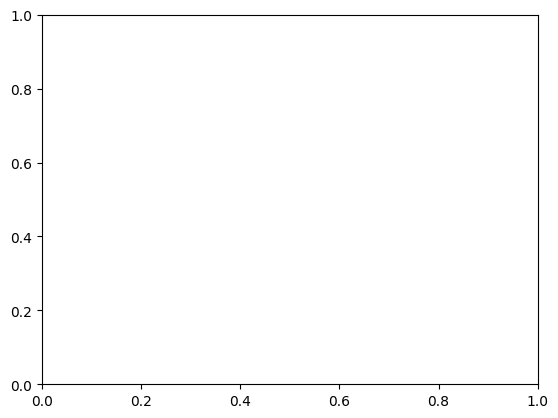

In [ ]:
import seaborn as sns

plt.plot(x=torch.arange(len(loss)), y=loss)